# Clustering Basato sulla Densità dei Siti di Monitoraggio della Rete con PROC MODECLUS


## Sintesi Esecutiva

Un'azienda di distribuzione elettrica utilizza PROC MODECLUS per individuare
cluster non parametrici, basati sulla densità, tra i suoi siti di
monitoraggio della rete (sottostazioni e sensori di alimentatore) usando
solo le loro coordinate geografiche. MODECLUS stima una superficie di
densità sui siti e tratta i cluster come regioni ad alta densità separate
da vuoti a bassa densità. Eseguendolo su 90 siti simulati con un raggio a
kernel uniforme di 3 km si recuperano le tre aree di servizio dense
costruite nei dati come i tre cluster più grandi (24, 24 e 21 siti),
mentre i siti rurali sparsi cadono in regioni rade e si separano nei
propri micro-cluster da uno o due siti. Quell'insieme di siti isolati è il
risultato operativo: una lista di candidati di asset remoti per il team di
pianificazione degli investimenti.


## Origine dei Dati

| Dataset | Righe | Descrizione |
|---------|------|-------------|
| `grid_sites` | 90 | Siti di monitoraggio elettrico sintetici generati inline con `call streaminit(70531)` e `rand()`. Tre aree di servizio dense (CentroUrbano, Periferia, Industriale) estratte da normali bivariate intorno a centroidi geografici distinti, più 22 siti Rurali sparsi estratti uniformemente sull'intero territorio. |

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `site_id` | Num | Identificativo univoco del sito di monitoraggio (1-90). |
| `region` | Char | Etichetta di pianificazione che registra come ogni sito è stato generato (CentroUrbano, Periferia, Industriale, Rurale); esclusa dal clustering. |
| `x_km`, `y_km` | Num | Posizione del sito in chilometri sulla griglia di pianificazione dell'azienda; le variabili di clustering. |
| `peak_load_mw` | Num | Carico di picco annuo osservato (MW) al sito; riportato per l'interpretazione a valle. |


# Clustering Basato sulla Densità dei Siti di Monitoraggio della Rete

Un'azienda regionale di distribuzione elettrica gestisce una rete di
**siti di monitoraggio** - sottostazioni e sensori di alimentatore -
distribuiti sul suo territorio di servizio. I pianificatori vogliono
raggruppare questi siti in **aree di servizio** naturali basate
esclusivamente sulla geografia, senza specificare in anticipo quanti
gruppi esistono, e identificare gli **asset rurali isolati** che non
appartengono a nessuna area densa.

`PROC MODECLUS` è adatta a questo compito: esegue un clustering
*non parametrico, basato sulla densità*. Stima una funzione di densità
sui siti, quindi tratta i cluster come regioni ad alta densità di siti
separate da vuoti a bassa densità. I valori anomali radi finiscono nei
propri piccoli cluster invece di essere assorbiti in un'area - esattamente
il comportamento che vogliamo per segnalare i siti remoti.

Questo notebook:
1. Genera una rete sintetica realistica di 90 siti.
2. Stima la densità dei siti con un **kernel uniforme** e scansiona il
   raggio di smoothing `R=` per confermare che le aree recuperate siano
   stabili.
3. Fissa un raggio di lavoro, scrive un dataset `OUT=` con la densità e
   l'etichetta di cluster di ogni sito, e mappa il risultato.


## Passo 1 - Generazione di una rete sintetica di siti di monitoraggio

Simuliamo 90 siti. Tre **aree di servizio** dense sono estratte da
distribuzioni normali bivariate intorno a centroidi geografici distinti
(CentroUrbano vicino a (12, 30), Periferia vicino a (30, 15), Industriale
vicino a (20, 42)), dando blocchi compatti ad alta densità di 24, 24 e 20
siti. Un quarto gruppo di 22 siti **Rurali** è estratto uniformemente sul
territorio, producendo i siti radi e sparsi che un'azienda tratterebbe
come isolati.

L'etichetta `region` registra come ogni sito è stato generato; la
**escludiamo deliberatamente** dal clustering cosicché MODECLUS
riscopra la struttura solo dalle coordinate. `peak_load_mw` viene
riportato per l'interpretazione successiva.


In [1]:
DATI grid_sites;
   CHIAMARE streaminit(70531);
   LUNGHEZZA region $ 12;

   /* Area di servizio urbana densa */
   FARE site_id = 1 FINO_A 24;
      region = 'CentroUrbano';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      USCITA;
   FINE;

   /* Area di periferia */
   FARE site_id = 25 FINO_A 48;
      region = 'Periferia';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      USCITA;
   FINE;

   /* Area industriale (carico di picco più alto) */
   FARE site_id = 49 FINO_A 68;
      region = 'Industriale';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      USCITA;
   FINE;

   /* Siti rurali sparsi (radi, basso carico) */
   FARE site_id = 69 FINO_A 90;
      region = 'Rurale';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      USCITA;
   FINE;
ESEGUIRE;

TITOLO 'Siti di Monitoraggio della Rete Sintetici';
PROCEDURA MEDIE DATI=grid_sites n mean std MIN MAX maxdec=2;
   CLASSE region;
   VARIABILE x_km y_km peak_load_mw;
   ETICHETTA region='Regione' x_km='X (km)' y_km='Y (km)' peak_load_mw='Carico di Picco (MW)';
ESEGUIRE;


                                       Siti di Monitoraggio della Rete Sintetici                                        

                                                  The MEANS Procedure

                                            Analysis Variable : x_km X (km)

        Regione               N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        CentroUrbano             24          12.07           1.34           8.65          14.42
        Industriale              20          20.36           0.96          18.52          21.53
        Periferia                24          29.96           1.73          26.51          33.60
        Rurale                   22          29.79          10.62          11.06          47.45
        ---------------------------------------------------------------------------------------

                                            Analysis Vari


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Siti di Monitoraggio della Rete Sintetici.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Le medie confermano tre aree compatte e un gruppo diffuso. Le tre regioni
dense hanno deviazioni standard di coordinate ridotte (circa 1-1.7 km su
ogni asse) intorno a centroidi ben separati, mentre il gruppo Rurale si
diffonde sull'intera griglia (deviazioni standard superiori a 10 km su
entrambi gli assi). Anche il carico di picco separa le aree - i siti
Industriali hanno una media di circa 6 MW, CentroUrbano circa 4.6 MW,
Periferia circa 2.7 MW, e i siti Rurali circa 1.5 MW - il che è un
contesto utile una volta individuati i cluster geografici.


## Passo 2 - Clustering di densità a kernel uniforme e scansione del raggio

La stima di densità a kernel uniforme usa un **raggio `R=`**: ogni sito
entro `R` chilometri contribuisce alla densità locale di un sito. Un `R`
piccolo dà una densità irregolare che frammenta il territorio; un `R`
grande esegue un oversmoothing e fonde le aree. Un esperto SAS non si
fida mai di un singolo valore - scansiona un intervallo di raggi e cerca
un numero di cluster che sia **stabile**, dove le aree dense persistono
mentre solo il conteggio dei singoletti sparsi va alla deriva.

Qui `M=1` seleziona il metodo di clustering 1 (il metodo non parametrico
standard), e richiediamo i raggi `R=2.5 to 4 by 0.5` in un'unica
chiamata. MODECLUS esegue l'analisi una volta per ogni raggio e riporta
il numero di cluster per ciascuno. `SHORT` sopprime le statistiche
dettagliate per cluster.


In [2]:
TITOLO 'Clustering di Densità a Kernel Uniforme dei Siti della Rete';
title2 'Scansione del Raggio R = 2.5 - 4.0 km';

PROCEDURA modeclus DATI=grid_sites m=1 r=2.5 FINO_A 4 PER 0.5 short;
   VARIABILE x_km y_km;
   id site_id;
ESEGUIRE;


                              Clustering di Densità a Kernel Uniforme dei Siti della Rete                               
                                         Scansione del Raggio R = 2.5 - 4.0 km                                          


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Clustering di Densità a Kernel Uniforme dei Siti della Rete.
NOTE: Option TITLE2 changed to Scansione del Raggio R = 2.5 - 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Il numero di cluster si muove solo lievemente lungo la scansione - 23
cluster a `R=2.5`, 22 a `R=3.0`, 19 a `R=3.5`, e 18 a `R=4.0`. I conteggi
grezzi elevati provengono dai siti rurali sparsi: ogni sito isolato si
trova nel proprio vicinato rado e forma un cluster di un solo sito,
quindi la maggior parte dei 18-23 "cluster" sono singoletti. Ciò che
rimane costante sotto la superficie è la struttura che conta - le tre
aree dense restano tre cluster grandi e ben separati a ogni raggio. Man
mano che `R` si allarga, alcuni dei singoletti sparsi si fondono con un
vicino o con un'area vicina, il che spiega perché il conteggio totale
va alla deriva lentamente verso il basso invece di oscillare
selvaggiamente. Quella stabilità è il segnale che la soluzione a tre
aree è reale e non un artefatto di un'unica banda.


## Passo 3 - Soluzione di cluster finale per la mappatura

Avendo visto che le tre aree sono stabili lungo la scansione, fissiamo un
singolo raggio di lavoro (`R=3` km) e richiediamo l'opzione **ALL** per
la visualizzazione completa per cluster, più **OUT=** per scrivere le
coordinate originali insieme alla stima di `DENSITY` e all'assegnazione
di `CLUSTER` così possiamo mappare il risultato. I cluster sono
numerati per densità di modo decrescente, quindi le aree più dense sono
i cluster 1, 2 e 3 e i siti radi prendono i numeri più alti.


In [3]:
TITOLO 'Soluzione Finale di Clustering Basato sulla Densità';
title2 'Kernel uniforme, R = 3 km';

PROCEDURA modeclus DATI=grid_sites m=1 r=3 out=join_out ALL;
   VARIABILE x_km y_km;
   id site_id;
ESEGUIRE;


                                  Soluzione Finale di Clustering Basato sulla Densità                                   
                                               Kernel uniforme, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to Soluzione Finale di Clustering Basato sulla Densità.
NOTE: Option TITLE2 changed to Kernel uniforme, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Il Riepilogo dei Cluster rende esplicita la struttura. La soluzione
`R=3` restituisce **22 cluster**, ma sono nettamente stratificati per
densità:

- **Cluster 1** - 24 siti, densità di modo circa 0.0090 (l'area
  CentroUrbano).
- **Cluster 2** - 24 siti, densità di modo circa 0.0079 (l'area
  Periferia).
- **Cluster 3** - 21 siti, densità di modo circa 0.0079 (l'area
  Industriale; include un sito rurale che è capitato sul suo bordo).
- **Cluster 4-22** - un gruppo di tre siti e diciotto cluster a un solo
  sito, tutti a densità di modo circa 0.0004, circa venti volte più
  radi delle aree.

Le tre aree dense rappresentano 69 dei 90 siti; i restanti 21 siti sono
gli asset rurali sparsi, ciascuno situato da solo o quasi da solo in un
vicinato a bassa densità. La densità, non un numero di cluster
prestabilito, traccia il confine tra un'area di servizio e un sito
isolato.


## Passo 4 - Mappatura dei cluster

Etichettiamo ogni sito in base al fatto che sia finito in una delle tre
aree dense (`cluster <= 3`) o in un micro-cluster raro, poi tracciamo
ogni sito alle sue coordinate colorato in base a quello stato. Questa è
la vista del pianificatore: aree dense da gestire come territori di
servizio, e siti isolati da segnalare per un trattamento separato.


                                       Aree di Servizio Recuperate e Siti Isolati                                       
                                   Clustering di densità a kernel uniforme, R = 3 km                                    




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Aree di Servizio Recuperate e Siti Isolati.
NOTE: Option TITLE2 changed to Clustering di densità a kernel uniforme, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


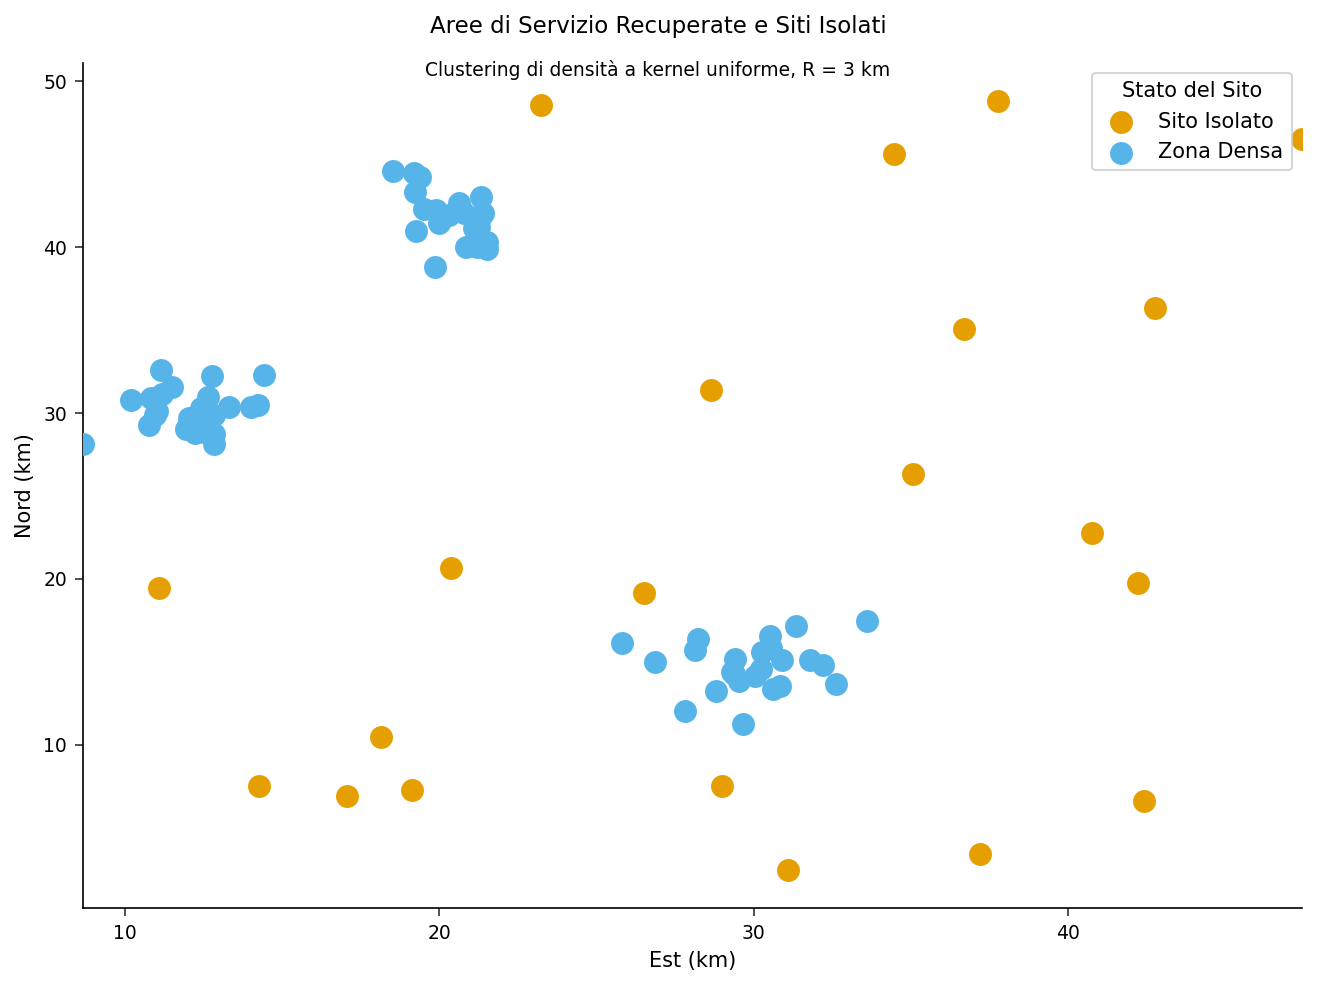

In [4]:
DATI mapped;
   IMPOSTARE join_out;
   LUNGHEZZA status $ 16;
   SE_COND CLUSTER <= 3 ALLORA status = 'Zona Densa';
   ALTRIMENTI status = 'Sito Isolato';
ESEGUIRE;

TITOLO 'Aree di Servizio Recuperate e Siti Isolati';
title2 'Clustering di densità a kernel uniforme, R = 3 km';
PROCEDURA SGPLOT DATI=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS ETICHETTA='Est (km)';
   YAXIS ETICHETTA='Nord (km)';
   keylegend / TITOLO='Stato del Sito';
ESEGUIRE;

TITOLO;


## Interpretazione dei Risultati

**Cosa ha trovato MODECLUS.** Guidata solo da `(x_km, y_km)`, la
procedura recupera le tre aree di servizio dense costruite nei dati -
i blob CentroUrbano, Periferia e Industriale - come i tre cluster più
grandi e più densi (24, 24 e 21 siti). I siti rurali sparsi, estratti
uniformemente sul territorio, cadono in regioni rade e si separano nei
propri cluster da uno o due siti invece di essere assorbiti in un'area.
Sulla mappa sono i punti separati dai tre blob compatti. Quell'insieme
isolato è il risultato operativo: una lista di candidati di asset
remoti per il team di pianificazione degli investimenti.

**Perché conta la scansione di smoothing.** Nessun singolo `R` è
autorevole per il clustering di densità non parametrico. Scansionare
`R=2.5 to 4 by 0.5` ci permette di confermare che le aree sono
*stabili* attraverso i livelli di smoothing invece di essere un
artefatto di un'unica banda. Lungo la scansione il numero di cluster si
muove solo da 23 fino a 18, e il cambiamento è interamente nel conteggio
dei singoletti sparsi - le tre aree dense persistono per tutta la
scansione. Dove la struttura è rimasta stabile così, abbiamo una
soluzione difendibile; se il conteggio fosse oscillato selvaggiamente,
la struttura sarebbe fragile e non dovrebbe guidare decisioni di
investimento.

**La densità stratifica il risultato.** Poiché i cluster sono numerati
per densità di modo decrescente, la separazione tra aree e siti isolati
è quantitativa, non arbitraria: le tre aree si collocano vicino a una
densità di modo di 0.008-0.009 mentre ogni sito isolato si colloca
vicino a 0.0004, circa venti volte più rado. Un pianificatore può
impostare una soglia di densità e leggere gli asset isolati
direttamente dalle colonne `CLUSTER` e `DENSITY` di `join_out`.

**Uso pratico.** Il dataset `join_out` assegna a ogni sito una densità
e un'etichetta di cluster che possono alimentare il lavoro a valle -
dimensionare squadre e ricambi per area di servizio, instradare
circuiti di ispezione, o dare priorità all'irrobustimento della rete
nel cluster industriale denso (il `peak_load_mw` più alto, circa 6 MW)
programmando al contempo i siti rurali isolati per una manutenzione
separata e meno frequente.

*Nota sui dati sintetici:* le coordinate e i carichi sono simulati con
un seme fisso (`call streaminit(70531)`) così il notebook è
completamente riproducibile offline; su dati reali di un'azienda si
sostituirebbero coordinate di siti rilevate e carichi di picco misurati.
Il numero esatto di cluster dipende dall'estrazione casuale e dal
raggio scelto.
